In [1]:
%load_ext autoreload
%autoreload 2

# 03 — Cluster Accuracy: Which Model Family Matches Ground Truth?

Week 2 anchor question: when model families disagree, which family matches the
wet-lab ground truth (`DMS_score_bin`)?

**Assays**: A4_HUMAN_Seuma_2022, ADRB2_HUMAN_Jones_2020, ACE2_HUMAN_Chan_2020,
AMIE_PSEAE_Wrenbeck_2017, A0A192B1T2_9HIV1_Haddox_2018

**Pipeline**: cluster the 95 models by pairwise agreement (κ) → per-model and
per-cluster accuracy against `DMS_score_bin` → cluster-vs-cluster showdown on
disagreement variants → ensemble comparison.

All figures → `results/figures/`, tables → `results/tables/`,
intermediates → `data/processed/`, log → `results/ARTIFACTS_LOG.csv`.


In [2]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data.proteingym_loader import load_dms_scores, get_model_columns
from src.analysis.clustering import assign_clusters, label_clusters_manually
from src.analysis.accuracy import (
    per_model_accuracy,
    per_model_accuracy_by_assay,
    cluster_majority_vote,
    per_cluster_accuracy,
    cluster_pairwise_showdown,
    cluster_showdown_by_assay,
)
from src.utils.persistence import save_figure, save_table, save_processed

NB = "03_cluster_accuracy"

sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams["figure.dpi"] = 120


## 1  Load data

Load the 5 pilots fresh (now carrying `DMS_score_bin`, ProteinGym's curator-assigned ground-truth label) and join the pre-computed `{model}_binary` columns and the pre-computed 95×95 pairwise κ matrix from `data/processed/` / `results/tables/`, rather than recomputing them.

In [3]:
PILOTS = [
    "A4_HUMAN_Seuma_2022",
    "ADRB2_HUMAN_Jones_2020",
    "ACE2_HUMAN_Chan_2020",
    "AMIE_PSEAE_Wrenbeck_2017",
    "A0A192B1T2_9HIV1_Haddox_2018",
]

raw = load_dms_scores("../data/raw", dms_ids=PILOTS)
models = get_model_columns(raw)

binarized = pd.read_parquet("../data/processed/pilot_binarized_scores.parquet")
df = raw[["dms_id", "mutant", "DMS_score_bin"]].merge(
    binarized, on=["dms_id", "mutant"], how="inner"
)

kappa = pd.read_csv("../results/tables/pairwise_kappa_matrix.csv", index_col=0)

print(f"{len(models)} models, {len(df):,} variants across {df['dms_id'].nunique()} assays")
print(f"Ground truth available for {df['DMS_score_bin'].notna().sum():,} / {len(df):,} variants")
print(f"kappa matrix: {kappa.shape}")


Loading assays:   0%|          | 0/5 [00:00<?, ?assay/s]

Loading assays:  20%|██        | 1/5 [00:00<00:01,  3.37assay/s]

Loading assays:  40%|████      | 2/5 [00:00<00:00,  3.02assay/s]

Loading assays:  80%|████████  | 4/5 [00:00<00:00,  5.30assay/s]

Loading assays: 100%|██████████| 5/5 [00:00<00:00,  6.06assay/s]

Loading assays: 100%|██████████| 5/5 [00:00<00:00,  5.14assay/s]


Proteins (UniProt IDs) : 5
DMS assays             : 5
Zero-shot models       : 95
Total variant rows     : 43,638
Models found           : ['Site_Independent', 'EVmutation', 'DeepSequence_single', 'DeepSequence_ensemble', 'EVE_single', 'EVE_ensemble']...

95 models, 43,638 variants across 5 assays
Ground truth available for 43,638 / 43,638 variants
kappa matrix: (95, 95)


## 2  Assign & label clusters

Ward hierarchical clustering on `1 - kappa` distance. `n_clusters=5` was chosen
after inspecting `n_clusters` in {4, 5, 6, 7}: 5 is the smallest value that
separates the MSA-based / evolutionary-coupling models (EVE, DeepSequence,
EVmutation, GEMME, ESCOTT, RSALOR, TranceptEVE) from the large
autoregressive/masked PLM family (ESM1, Progen2, RITA, Tranception, xTrimoPGLM,
MSA_Transformer) — at `n_clusters=4` those two merge into one block. Beyond 5,
extra clusters mostly just split off a handful of ProtSSN checkpoints without
adding an interpretable new family, so 5 is kept.


In [4]:
cluster_ids = assign_clusters(kappa, n_clusters=5, method="ward")
print(cluster_ids.value_counts())
print()
for cid in sorted(cluster_ids.unique()):
    print(f"--- {cid} ---")
    print(sorted(cluster_ids[cluster_ids == cid].index.tolist()))
    print()


cluster_id
cluster_2    33
cluster_1    20
cluster_3    15
cluster_4    14
cluster_0    13
Name: count, dtype: int64

--- cluster_0 ---
['ESM2_650M', 'ProtSSN_ensemble', 'ProtSSN_k10_h1280', 'ProtSSN_k10_h512', 'ProtSSN_k10_h768', 'ProtSSN_k20_h1280', 'ProtSSN_k20_h512', 'ProtSSN_k20_h768', 'ProtSSN_k30_h1280', 'ProtSSN_k30_h512', 'ProtSSN_k30_h768', 'S2F', 'S3F']

--- cluster_1 ---
['CARP_600K', 'ESM-IF1', 'ESM2_150M', 'ESM2_35M', 'ESM2_8M', 'ESM3', 'MIF', 'MULAN_small', 'ProSST-1024', 'ProSST-128', 'ProSST-20', 'ProSST-2048', 'ProSST-4096', 'ProSST-512', 'ProteinMPNN', 'SaProt_35M_AF2', 'SaProt_650M_AF2', 'Unirep', 'VenusREM', 'xTrimoPGLM-7B-CLM']

--- cluster_2 ---
['ESM1b', 'ESM1v_ensemble', 'ESM1v_single', 'ESM2_15B', 'ESM2_3B', 'MSA_Transformer_ensemble', 'MSA_Transformer_single', 'Progen2_base', 'Progen2_large', 'Progen2_medium', 'Progen2_small', 'Progen2_xlarge', 'RITA_l', 'RITA_m', 'RITA_s', 'RITA_xl', 'Tranception_L', 'Tranception_L_no_retrieval', 'Tranception_M', 'Tranceptio

Manual labels, based on architecture/training-signal of the member models:

| cluster    | label                    | dominant character                                                        |
|------------|---------------------------|----------------------------------------------------------------------------|
| cluster_0  | `structure_aware`        | ProtSSN (structure-graph) family, S2F/S3F (structure-informed)             |
| cluster_1  | `inverse_folding_mixed`  | ESM-IF1, ProteinMPNN, MIF (inverse folding) + SaProt/ProSST (struct tokens) + small ESM2 |
| cluster_2  | `autoregressive_plm`     | ESM1/2, Progen2, RITA, Tranception, xTrimoPGLM, MSA_Transformer, VESPA      |
| cluster_3  | `msa_based`              | EVE, DeepSequence, EVmutation, GEMME, ESCOTT, RSALOR, SiteRM, TranceptEVE   |
| cluster_4  | `newer_plm`              | CARP, ESMC, MIFST, PoET, Progen3, ProtGPT2 (2023-24 model families)         |


In [5]:
CLUSTER_LABELS = {
    "cluster_0": "structure_aware",
    "cluster_1": "inverse_folding_mixed",
    "cluster_2": "autoregressive_plm",
    "cluster_3": "msa_based",
    "cluster_4": "newer_plm",
}

cluster_assignments = label_clusters_manually(cluster_ids, CLUSTER_LABELS)
print(cluster_assignments["cluster_label"].value_counts())

save_processed(
    cluster_assignments, "model_cluster_assignments", notebook=NB,
    description="Model -> cluster_id/cluster_label mapping (Ward clustering, n=5, on 1-kappa distance)",
)
save_table(
    cluster_assignments, "model_cluster_assignments", notebook=NB,
    description="Model -> cluster_id/cluster_label mapping (Ward clustering, n=5, on 1-kappa distance)",
)


cluster_label
autoregressive_plm       33
inverse_folding_mixed    20
msa_based                15
newer_plm                14
structure_aware          13
Name: count, dtype: int64


  [saved processed] data/processed/model_cluster_assignments.parquet
  [saved table]  results/tables/model_cluster_assignments.csv


PosixPath('/Users/naodaraya/variant-disagreement-atlas/results/tables/model_cluster_assignments.csv')

## 3  Per-model accuracy (MCC primary)

In [6]:
model_acc = per_model_accuracy(df, models).join(cluster_assignments["cluster_label"])
model_acc = model_acc.sort_values("mcc", ascending=False)

save_table(
    model_acc, "per_model_accuracy", notebook=NB,
    description="Accuracy/precision/recall/F1/MCC of each of the 95 models vs. DMS_score_bin, pooled across 5 pilots",
)

cluster_avg_mcc = model_acc.groupby("cluster_label")["mcc"].mean().sort_values(ascending=False)
print(cluster_avg_mcc)
model_acc.head(10)


  [saved table]  results/tables/per_model_accuracy.csv
cluster_label
msa_based                0.363296
newer_plm                0.341555
autoregressive_plm       0.325376
structure_aware          0.310322
inverse_folding_mixed    0.241859
Name: mcc, dtype: float64


,accuracy,precision,recall,f1,mcc,n,cluster_label
ESCOTT,0.704111,0.699212,0.706073,0.702626,0.408241,43638,msa_based
S3F_MSA,0.700009,0.695100,0.701953,0.698510,0.400037,43638,msa_based
RSALOR,0.694784,0.689927,0.696538,0.693217,0.389584,43638,msa_based
GEMME,0.694693,0.689783,0.696584,0.693167,0.389403,43638,msa_based
PoET,0.694372,0.689462,0.696260,0.692844,0.388762,43638,newer_plm
S2F_MSA,0.692951,0.688041,0.694825,0.691417,0.385920,43638,msa_based
VenusREM,0.691209,0.686300,0.693066,0.689666,0.382437,43638,inverse_folding_mixed
TranceptEVE_S,0.689651,0.684741,0.691492,0.688100,0.379320,43638,msa_based
Tranception_S,0.688230,0.683320,0.690057,0.686672,0.376478,43638,autoregressive_plm
ESM1v_ensemble,0.687864,0.682954,0.689687,0.686304,0.375745,43638,autoregressive_plm


  [saved figure] results/figures/per_model_accuracy_bar.png


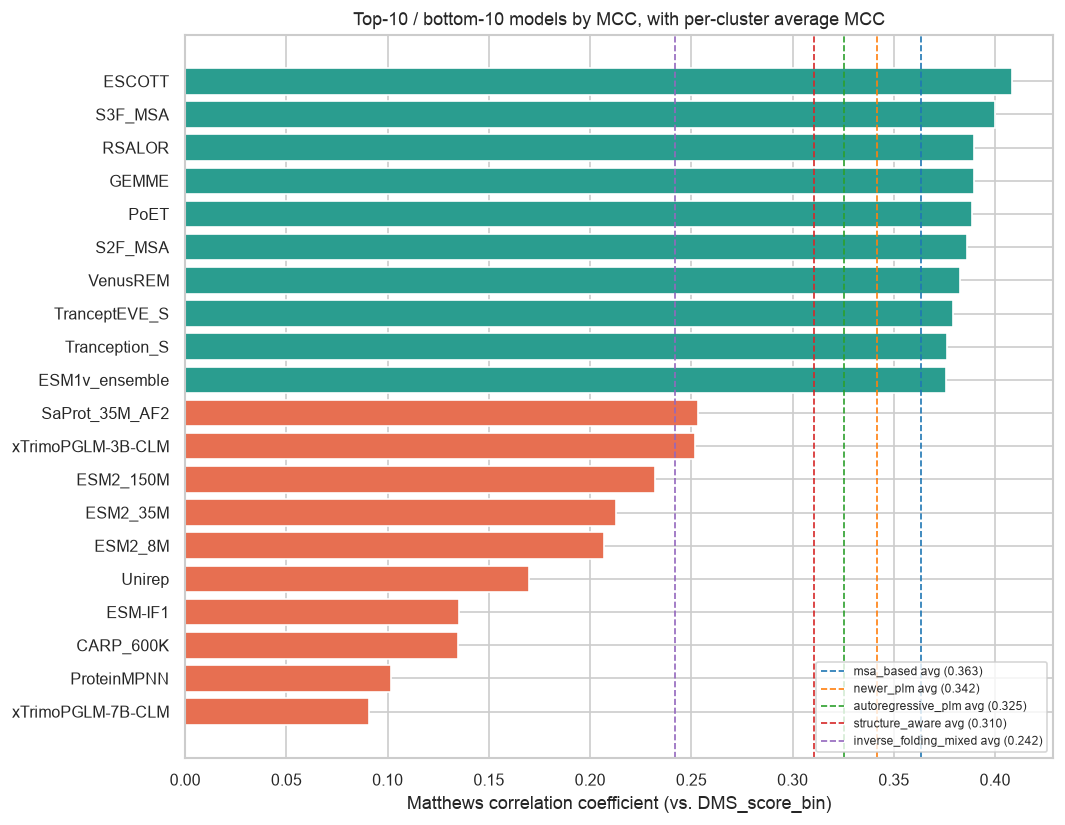

In [7]:
top10 = model_acc.head(10)
bottom10 = model_acc.tail(10)
plot_df = pd.concat([top10, bottom10])

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#2a9d8f" if m in top10.index else "#e76f51" for m in plot_df.index]
ax.barh(plot_df.index[::-1], plot_df["mcc"][::-1], color=colors[::-1])

palette = sns.color_palette("tab10", len(cluster_avg_mcc))
for (cluster, avg), color in zip(cluster_avg_mcc.items(), palette):
    ax.axvline(avg, linestyle="--", linewidth=1, color=color, label=f"{cluster} avg ({avg:.3f})")

ax.set_xlabel("Matthews correlation coefficient (vs. DMS_score_bin)")
ax.set_title("Top-10 / bottom-10 models by MCC, with per-cluster average MCC")
ax.legend(fontsize=7, loc="lower right")
plt.tight_layout()

save_figure(
    fig, "per_model_accuracy_bar", notebook=NB,
    description="Top-10 and bottom-10 models by MCC vs. DMS_score_bin, with horizontal per-cluster average MCC reference lines",
)
plt.show()


## 4  Per-model accuracy by assay → heatmap

Which models are best on which proteins?

  [saved table]  results/tables/per_model_accuracy_by_assay.csv


  [saved figure] results/figures/per_model_accuracy_by_assay_heatmap.png


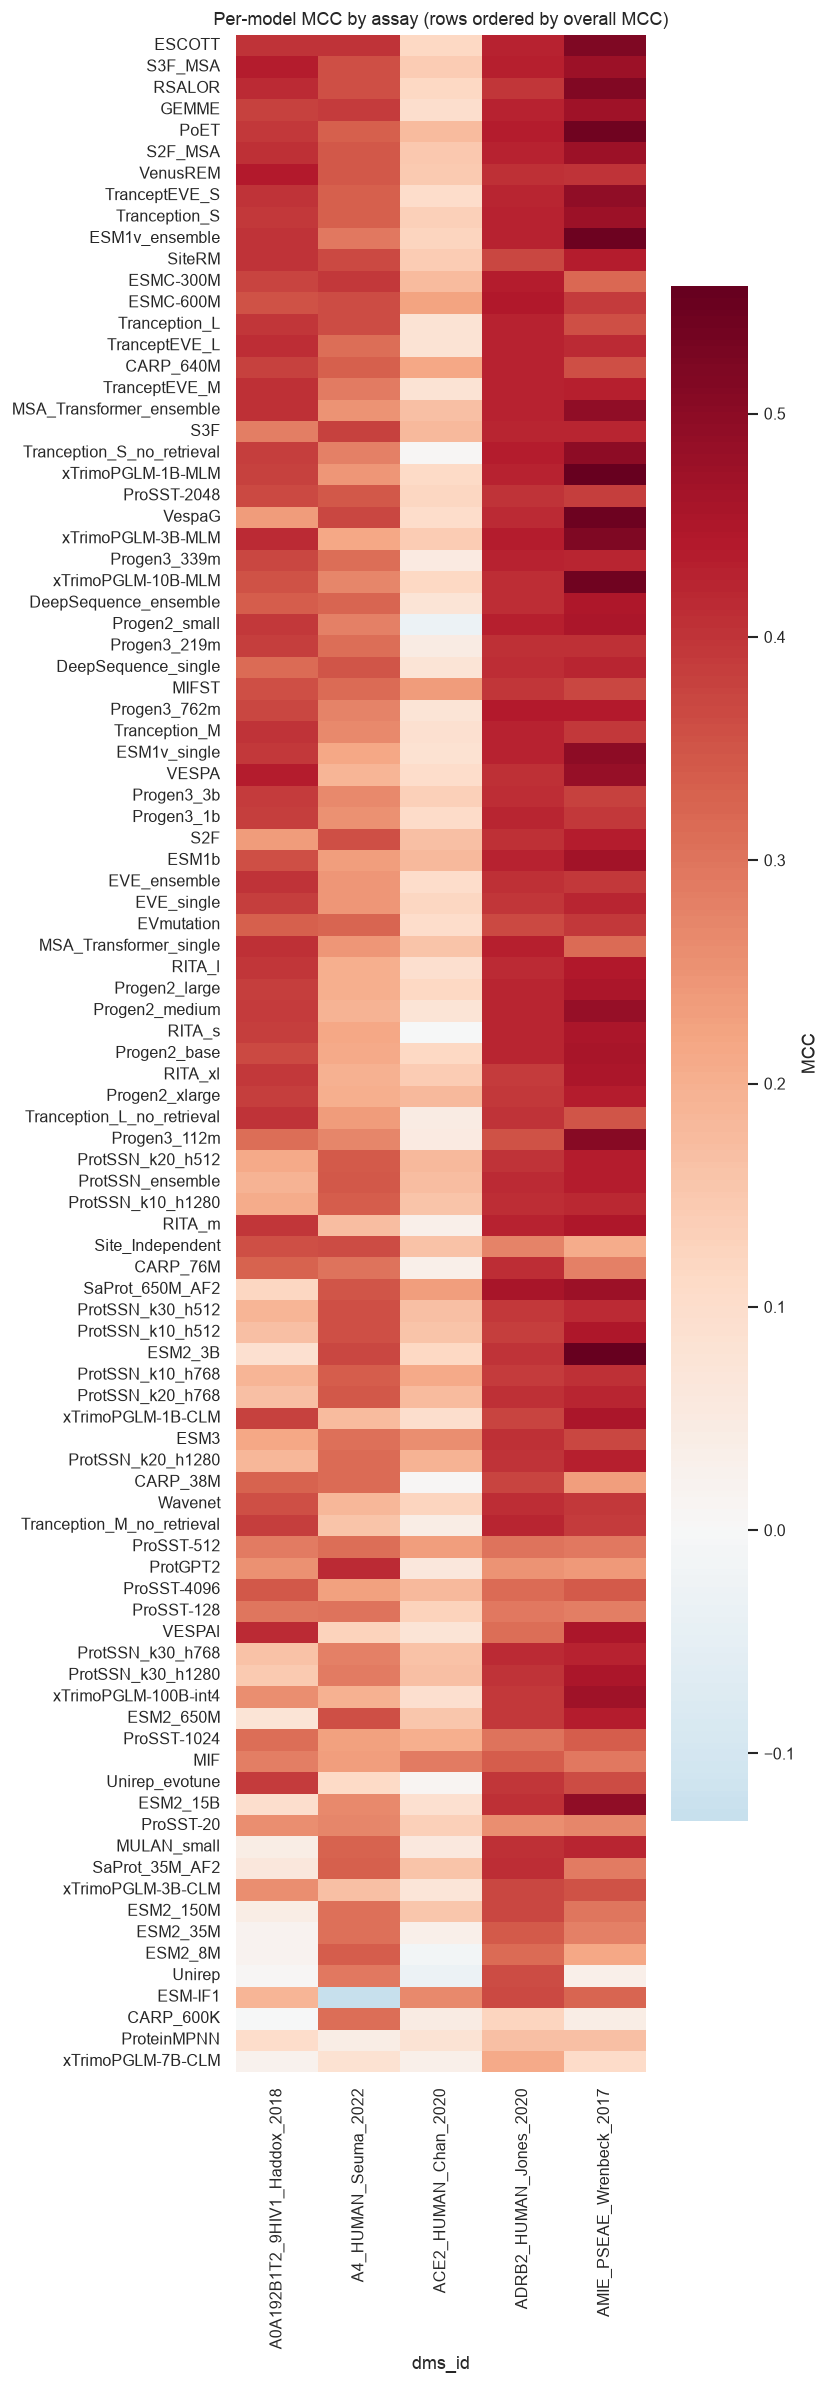

In [8]:
model_acc_by_assay = per_model_accuracy_by_assay(df, models)
save_table(
    model_acc_by_assay, "per_model_accuracy_by_assay", notebook=NB,
    description="Accuracy/precision/recall/F1/MCC of each of the 95 models vs. DMS_score_bin, per pilot assay",
)

mcc_pivot = model_acc_by_assay.pivot(index="model", columns="dms_id", values="mcc")
mcc_pivot = mcc_pivot.loc[model_acc.index]  # order by overall MCC rank

fig, ax = plt.subplots(figsize=(7, 20))
sns.heatmap(mcc_pivot, cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label": "MCC"})
ax.set_title("Per-model MCC by assay (rows ordered by overall MCC)")
plt.tight_layout()

save_figure(
    fig, "per_model_accuracy_by_assay_heatmap", notebook=NB,
    description="95 models x 5 assays heatmap of MCC vs. DMS_score_bin, rows ordered by overall MCC",
)
plt.show()


## 5  Per-cluster majority-vote accuracy

In [9]:
cluster_votes = cluster_majority_vote(df, cluster_assignments["cluster_label"])
cluster_acc = per_cluster_accuracy(df, cluster_votes)

save_table(
    cluster_acc, "per_cluster_accuracy", notebook=NB,
    description="Accuracy/precision/recall/F1/MCC of each cluster's majority vote vs. DMS_score_bin, overall (dms_id='ALL') and per assay",
)

overall = cluster_acc[cluster_acc["dms_id"] == "ALL"].sort_values("mcc", ascending=False)
print(overall[["cluster", "mcc", "accuracy", "n"]].to_string(index=False))


  [saved table]  results/tables/per_cluster_accuracy.csv
              cluster      mcc  accuracy     n
            newer_plm 0.414933  0.707430 41966
            msa_based 0.391463  0.695747 43638
   autoregressive_plm 0.372609  0.686306 43638
inverse_folding_mixed 0.341584  0.670800 41938
      structure_aware 0.323828  0.661900 43638


  [saved figure] results/figures/per_cluster_accuracy_bars.png


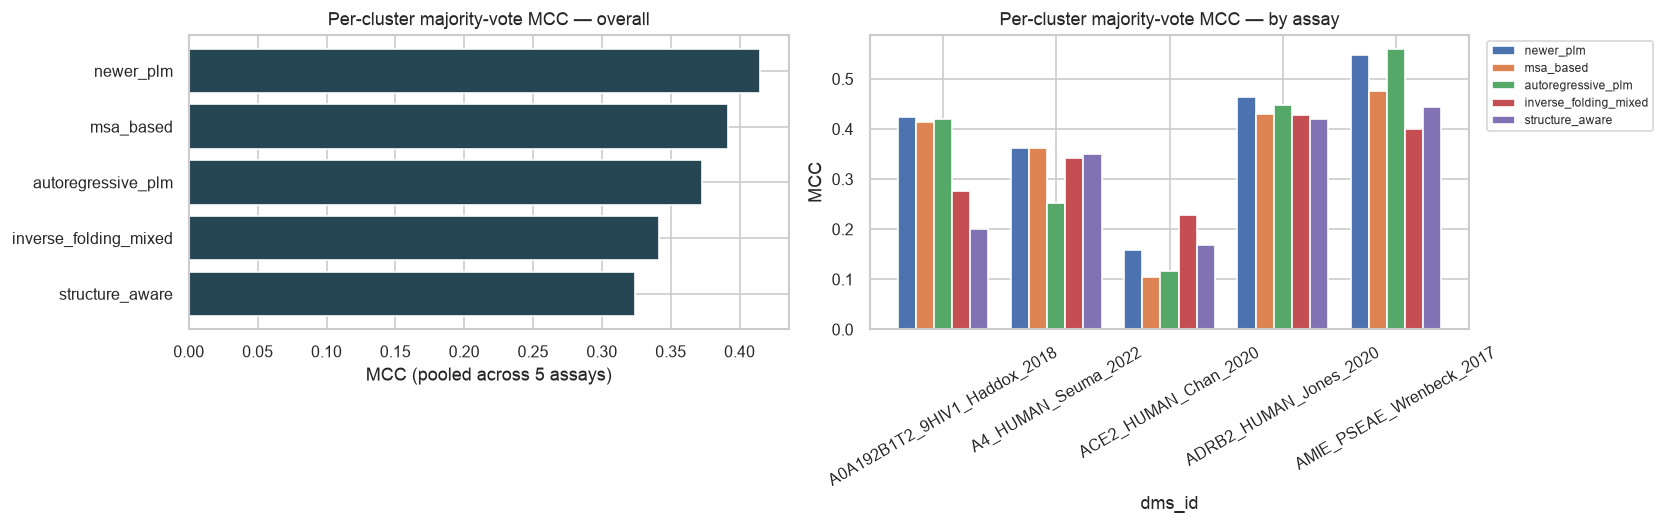

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

overall_sorted = overall.set_index("cluster")["mcc"].sort_values()
axes[0].barh(overall_sorted.index, overall_sorted.values, color="#264653")
axes[0].set_xlabel("MCC (pooled across 5 assays)")
axes[0].set_title("Per-cluster majority-vote MCC — overall")

per_assay = cluster_acc[cluster_acc["dms_id"] != "ALL"]
per_assay_pivot = per_assay.pivot(index="dms_id", columns="cluster", values="mcc")
per_assay_pivot = per_assay_pivot[overall_sorted.index[::-1]]
per_assay_pivot.plot(kind="bar", ax=axes[1], width=0.8)
axes[1].set_ylabel("MCC")
axes[1].set_title("Per-cluster majority-vote MCC — by assay")
axes[1].legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
save_figure(
    fig, "per_cluster_accuracy_bars", notebook=NB,
    description="Per-cluster majority-vote MCC vs. DMS_score_bin, overall and broken out per assay",
)
plt.show()


## 6  Cluster pairwise showdown — the money analysis

For every pair of clusters, restrict to variants where their majority votes
*disagree*, and ask: which cluster's call matches `DMS_score_bin` more often?


In [11]:
showdown = cluster_pairwise_showdown(df, cluster_votes)
save_table(
    showdown, "cluster_showdown", notebook=NB,
    description="Pairwise cluster showdown: on variants where cluster A and B's majority votes disagree, win rate of A vs B and disagreement count",
)
print(showdown.to_string(index=False))


  [saved table]  results/tables/cluster_showdown.csv
            cluster_a             cluster_b  n_disagree  a_win_pct  b_win_pct
   autoregressive_plm inverse_folding_mixed       10937  53.259578  46.740422
   autoregressive_plm             msa_based        7330  47.189632  52.810368
   autoregressive_plm             newer_plm        5824  44.213599  55.786401
   autoregressive_plm       structure_aware       11461  54.646191  45.353809
inverse_folding_mixed             msa_based       10786  44.872983  55.127017
inverse_folding_mixed             newer_plm        6567  40.414192  59.585808
inverse_folding_mixed       structure_aware        7156  51.285634  48.714366
            msa_based             newer_plm        6461  48.104009  51.895991
            msa_based       structure_aware       10937  56.752309  43.247691
            newer_plm       structure_aware        8322  60.105744  39.894256


  [saved figure] results/figures/cluster_showdown_matrix.png


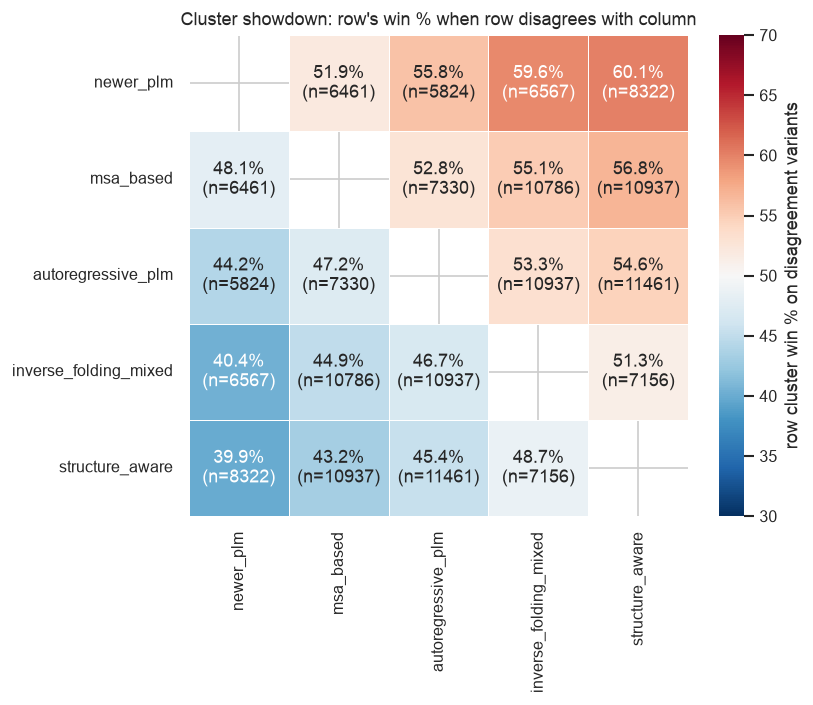

In [12]:
clusters_sorted = overall_sorted.index[::-1].tolist()  # best MCC first
win_matrix = pd.DataFrame(np.nan, index=clusters_sorted, columns=clusters_sorted)
n_matrix = pd.DataFrame(0, index=clusters_sorted, columns=clusters_sorted)
for _, row in showdown.iterrows():
    a, b = row["cluster_a"], row["cluster_b"]
    win_matrix.loc[a, b] = row["a_win_pct"]
    win_matrix.loc[b, a] = row["b_win_pct"]
    n_matrix.loc[a, b] = n_matrix.loc[b, a] = row["n_disagree"]

annot = win_matrix.round(1).astype(str) + "%\n(n=" + n_matrix.astype(str) + ")"
np.fill_diagonal(annot.values, "")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    win_matrix, annot=annot, fmt="", cmap="RdBu_r", center=50,
    vmin=30, vmax=70, ax=ax, cbar_kws={"label": "row cluster win % on disagreement variants"},
    linewidths=0.5,
)
ax.set_title("Cluster showdown: row's win % when row disagrees with column")
plt.tight_layout()

save_figure(
    fig, "cluster_showdown_matrix", notebook=NB,
    description="Heatmap of pairwise cluster showdown win rates and disagreement-variant counts, pooled across 5 pilots",
)
plt.show()


## 7  Per-assay cluster showdown

Does the winning cluster depend on the protein?

  [saved table]  results/tables/cluster_showdown_by_assay.csv


  [saved figure] results/figures/per_assay_cluster_showdowns.png


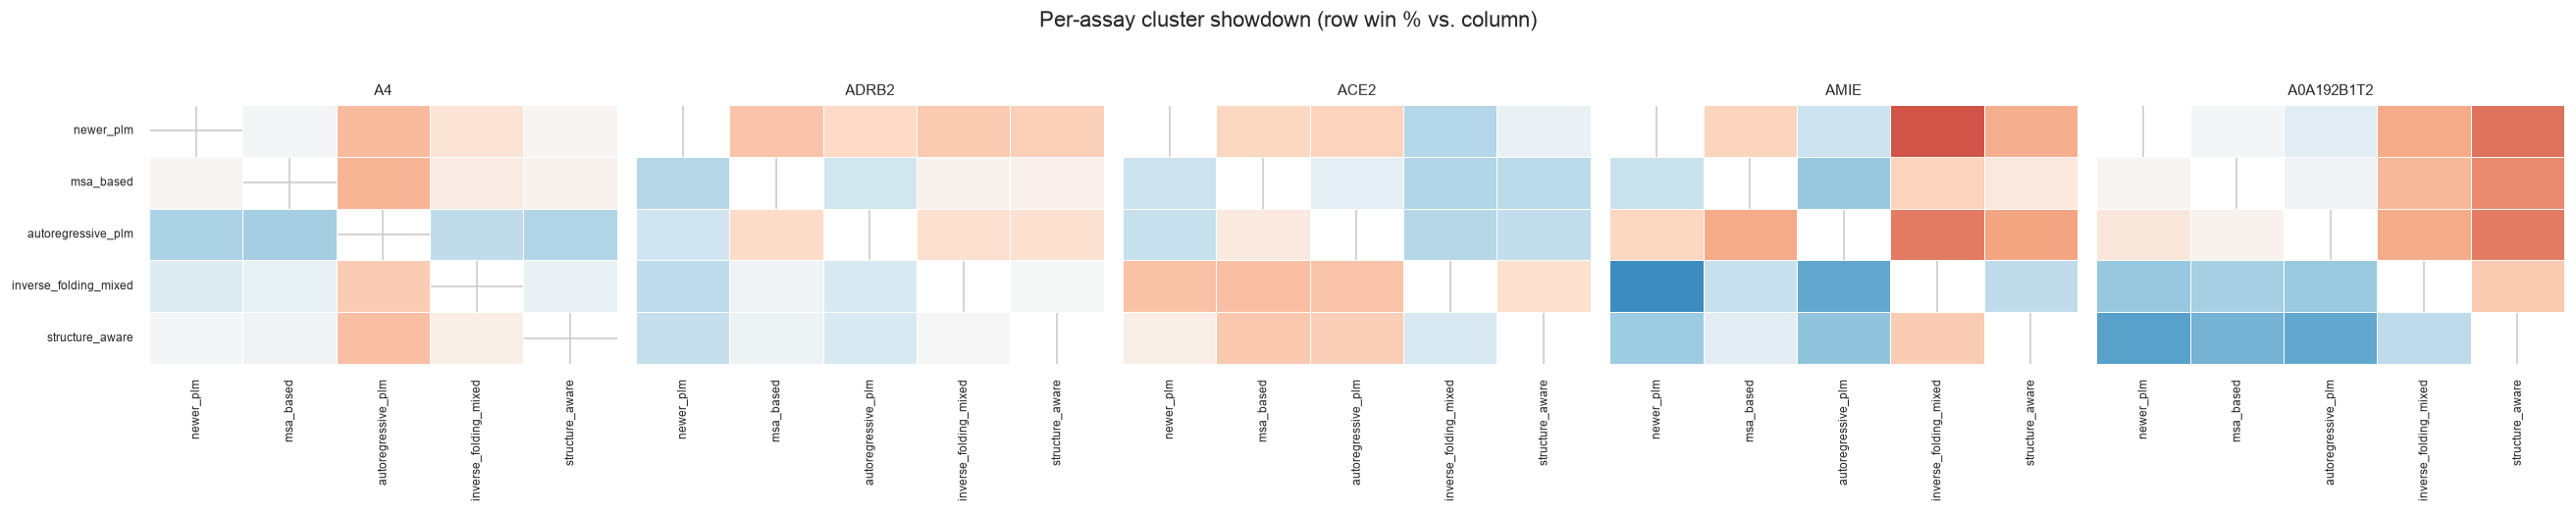

In [13]:
showdown_by_assay = cluster_showdown_by_assay(df, cluster_votes)
save_table(
    showdown_by_assay, "cluster_showdown_by_assay", notebook=NB,
    description="Pairwise cluster showdown win rates and disagreement counts, stratified by pilot assay",
)

fig, axes = plt.subplots(1, len(PILOTS), figsize=(22, 4.2))
for ax, pid in zip(axes, PILOTS):
    sub = showdown_by_assay[showdown_by_assay["dms_id"] == pid]
    wm = pd.DataFrame(np.nan, index=clusters_sorted, columns=clusters_sorted)
    nm = pd.DataFrame(0, index=clusters_sorted, columns=clusters_sorted)
    for _, row in sub.iterrows():
        a, b = row["cluster_a"], row["cluster_b"]
        wm.loc[a, b] = row["a_win_pct"]
        wm.loc[b, a] = row["b_win_pct"]
        nm.loc[a, b] = nm.loc[b, a] = row["n_disagree"]
    sns.heatmap(
        wm, cmap="RdBu_r", center=50, vmin=20, vmax=80, ax=ax,
        cbar=False, linewidths=0.3, xticklabels=True, yticklabels=(ax is axes[0]),
    )
    ax.set_title(pid.split("_")[0], fontsize=9)
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

plt.suptitle("Per-assay cluster showdown (row win % vs. column)", y=1.03)
plt.tight_layout()

save_figure(
    fig, "per_assay_cluster_showdowns", notebook=NB,
    description="Small-multiples of the cluster showdown win-rate matrix, one panel per pilot assay",
)
plt.show()


## 8  Best model per protein

In [14]:
best_per_protein = (
    model_acc_by_assay.loc[model_acc_by_assay.groupby("dms_id")["mcc"].idxmax()]
    .merge(cluster_assignments["cluster_label"], left_on="model", right_index=True)
    .sort_values("dms_id")
    [["dms_id", "model", "cluster_label", "mcc", "accuracy", "f1", "n"]]
    .reset_index(drop=True)
)
save_table(
    best_per_protein, "best_model_per_protein", notebook=NB,
    description="Single best model (by MCC) per pilot assay, with its cluster label",
)
best_per_protein


  [saved table]  results/tables/best_model_per_protein.csv


,dms_id,model,cluster_label,mcc,accuracy,f1,n
0,A0A192B1T2_9HIV1_Haddox_2018,VenusREM,inverse_folding_mixed,0.444061,0.720681,0.704368,12577
1,A4_HUMAN_Seuma_2022,ProtGPT2,newer_plm,0.412249,0.705692,0.714893,14811
2,ACE2_HUMAN_Chan_2020,MIF,inverse_folding_mixed,0.287449,0.643725,0.643564,2223
3,ADRB2_HUMAN_Jones_2020,SaProt_650M_AF2,inverse_folding_mixed,0.456923,0.728462,0.728462,7800
4,AMIE_PSEAE_Wrenbeck_2017,ESM2_3B,autoregressive_plm,0.557090,0.778545,0.778545,6227


## 9  Ensemble analysis

- **All-model ensemble**: majority vote (mean > 0.5) across all 95 models' binary calls.
- **Family-diverse ensemble**: one top model per cluster (highest overall MCC within that cluster), majority vote across the resulting 5 calls (odd count, no ties).


In [15]:
all_binary_cols = [f"{m}_binary" for m in models]
mean_vote_all = df[all_binary_cols].astype(float).mean(axis=1)
ensemble_all = pd.Series(pd.NA, index=df.index, dtype="Int8")
ensemble_all[mean_vote_all > 0.5] = 1
ensemble_all[mean_vote_all < 0.5] = 0

top_per_cluster = model_acc.reset_index().rename(columns={"index": "model"})
top_per_cluster = top_per_cluster.loc[top_per_cluster.groupby("cluster_label")["mcc"].idxmax()]
diverse_models = top_per_cluster["model"].tolist()
print("Family-diverse ensemble members:", diverse_models)

diverse_cols = [f"{m}_binary" for m in diverse_models]
mean_vote_diverse = df[diverse_cols].astype(float).mean(axis=1)
ensemble_diverse = pd.Series(pd.NA, index=df.index, dtype="Int8")
ensemble_diverse[mean_vote_diverse > 0.5] = 1
ensemble_diverse[mean_vote_diverse < 0.5] = 0

votes_df = pd.DataFrame({
    "all_model_ensemble": ensemble_all,
    "family_diverse_ensemble": ensemble_diverse,
})
ensemble_acc = per_cluster_accuracy(df, votes_df)


Family-diverse ensemble members: ['Tranception_S', 'VenusREM', 'ESCOTT', 'PoET', 'S3F']


In [16]:
rows = []
for dms_id in PILOTS + ["ALL"]:
    if dms_id == "ALL":
        best_single_mcc = model_acc["mcc"].max()
        best_single_model = model_acc["mcc"].idxmax()
    else:
        best_row = model_acc_by_assay[model_acc_by_assay["dms_id"] == dms_id].sort_values("mcc", ascending=False).iloc[0]
        best_single_mcc = best_row["mcc"]
        best_single_model = best_row["model"]
    all_mcc = ensemble_acc.query("cluster=='all_model_ensemble' and dms_id==@dms_id")["mcc"].iloc[0]
    diverse_mcc = ensemble_acc.query("cluster=='family_diverse_ensemble' and dms_id==@dms_id")["mcc"].iloc[0]
    rows.append({
        "dms_id": dms_id,
        "best_single_model": best_single_model,
        "best_single_mcc": best_single_mcc,
        "all_model_ensemble_mcc": all_mcc,
        "family_diverse_ensemble_mcc": diverse_mcc,
    })

ensemble_comparison = pd.DataFrame(rows)
save_table(
    ensemble_comparison, "ensemble_comparison", notebook=NB,
    description="Best single model vs. all-95-model ensemble vs. family-diverse (one-per-cluster) ensemble, MCC per assay and pooled",
)
ensemble_comparison


  [saved table]  results/tables/ensemble_comparison.csv


,dms_id,best_single_model,best_single_mcc,all_model_ensemble_mcc,family_diverse_ensemble_mcc
0,A4_HUMAN_Seuma_2022,ProtGPT2,0.412249,0.375162,0.387071
1,ADRB2_HUMAN_Jones_2020,SaProt_650M_AF2,0.456923,0.457045,0.452831
2,ACE2_HUMAN_Chan_2020,MIF,0.287449,0.159794,0.168731
3,AMIE_PSEAE_Wrenbeck_2017,ESM2_3B,0.557090,0.558449,0.552943
4,A0A192B1T2_9HIV1_Haddox_2018,VenusREM,0.444061,0.430811,0.442621
5,ALL,ESCOTT,0.408241,0.422085,0.426862


  [saved figure] results/figures/ensemble_vs_best_single.png


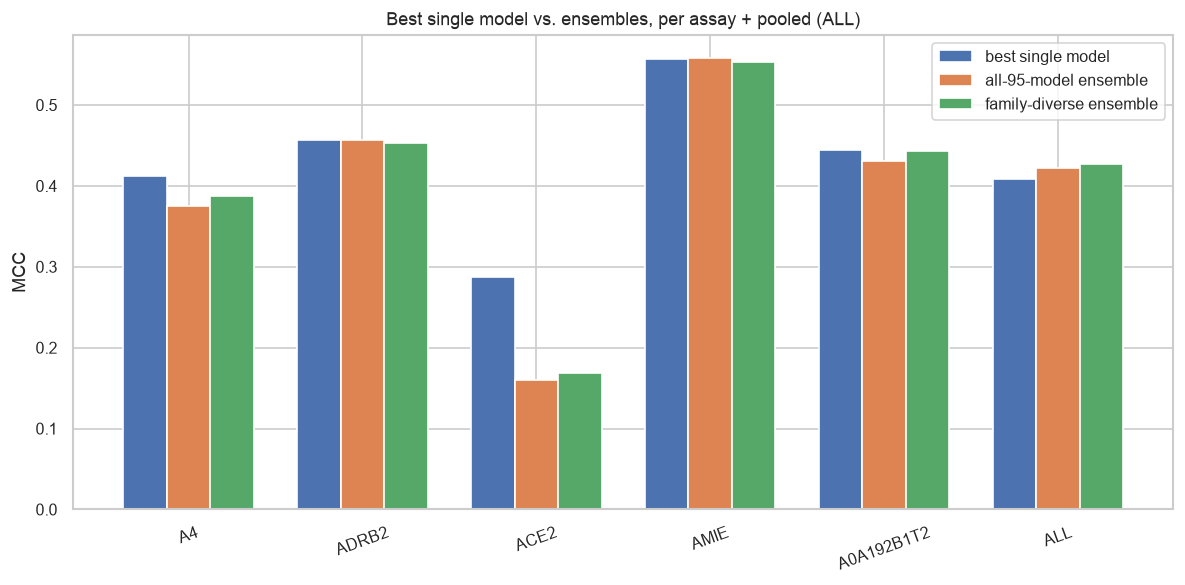

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ensemble_comparison))
width = 0.25
ax.bar(x - width, ensemble_comparison["best_single_mcc"], width, label="best single model")
ax.bar(x, ensemble_comparison["all_model_ensemble_mcc"], width, label="all-95-model ensemble")
ax.bar(x + width, ensemble_comparison["family_diverse_ensemble_mcc"], width, label="family-diverse ensemble")
ax.set_xticks(x)
ax.set_xticklabels([d.split("_")[0] for d in ensemble_comparison["dms_id"]], rotation=20)
ax.set_ylabel("MCC")
ax.set_title("Best single model vs. ensembles, per assay + pooled (ALL)")
ax.legend()
plt.tight_layout()

save_figure(
    fig, "ensemble_vs_best_single", notebook=NB,
    description="MCC comparison of best single model, all-model ensemble, and family-diverse ensemble, per assay and pooled",
)
plt.show()


## Week 2 findings

Anchor question: when model families disagree, which family matches wet-lab ground truth (`DMS_score_bin`)?

**Clustering.** Ward clustering on 1-kappa (n_clusters=5) recovers five interpretable families: `autoregressive_plm` (33 models — ESM1/2, Progen2, RITA, Tranception, xTrimoPGLM, MSA_Transformer), `inverse_folding_mixed` (20 — ESM-IF1, ProteinMPNN, MIF, SaProt, ProSST, small ESM2), `msa_based` (15 — EVE, DeepSequence, EVmutation, GEMME, ESCOTT, RSALOR, TranceptEVE), `newer_plm` (14 — CARP, ESMC, PoET, Progen3, ProtGPT2), `structure_aware` (13 — ProtSSN family, S2F/S3F).

**Per-cluster overall MCC (pooled across 5 pilots), majority vote vs. DMS_score_bin:**
- `newer_plm`: **0.415** (highest)
- `msa_based`: 0.391
- `autoregressive_plm`: 0.373
- `inverse_folding_mixed`: 0.342
- `structure_aware`: 0.324 (lowest)

**Winning cluster:** `newer_plm` — despite being the smallest cluster (14 models, dominated by 2023-24 releases: ESMC, PoET, Progen3), it has the highest overall MCC *and* wins its pairwise showdown against every other cluster on variants where they disagree: beats `structure_aware` 60.1%, `inverse_folding_mixed` 59.6%, `autoregressive_plm` 55.8%, and `msa_based` 51.9% of the time. `structure_aware` is the consistent loser, both in overall MCC and in every pairwise showdown.

**Protein-specific patterns — the winning cluster is NOT universal:**
- `newer_plm` wins on 3/5 assays: A4_HUMAN (TP53, MCC 0.363), ADRB2_HUMAN (0.463), and A0A192B1T2_HIV1/Env (0.423).
- `autoregressive_plm` wins on AMIE_PSEAE (bacterial enzyme, MCC 0.559 — the highest single-assay MCC of the whole analysis), consistent with the hypothesis that large PLM language-model priors do especially well on well-conserved, well-studied bacterial enzyme families.
- `inverse_folding_mixed` wins on ACE2_HUMAN, but at a much lower absolute MCC (0.228) — ACE2 appears to be a hard assay for every cluster, so this win is a weak signal, not a strong preference.
- No single cluster wins on HIV Env by a wide margin over `msa_based` (0.423 vs 0.415), consistent with the idea that hypervariable viral proteins are agnostic to MSA-based vs. newer-PLM approaches once both have degraded from lack of stable alignments.

**Best single model per protein:** ESCOTT (msa_based) is the best single model pooled across all assays (MCC 0.408), but per-assay winners are all different models: VenusREM (HIV Env), ProtGPT2 (A4_HUMAN), MIF (ACE2_HUMAN), SaProt_650M_AF2 (ADRB2_HUMAN), ESM2_3B (AMIE_PSEAE) — no single model dominates across proteins, reinforcing that model choice should be protein-aware.

**Ensembles:** the family-diverse ensemble (one top model per cluster, 5-way majority vote) beats the all-95-model ensemble pooled (MCC 0.427 vs 0.422) and on 3/5 assays, despite using only 5 models instead of 95 — evidence that model diversity (across families) matters more than raw model count. Neither ensemble beats the single best per-assay model on AMIE_PSEAE or ADRB2_HUMAN, where one model family clearly dominates and adding weaker clusters' votes dilutes the signal.

**Implication for write-up:** disagreement resolution isn't "pick the best family" — it's protein-dependent. `newer_plm` is the best default, but bacterial enzymes favor `autoregressive_plm`, and hypervariable proteins show no strong family preference. A protein-type-aware routing rule (or the family-diverse ensemble) looks more promising than crowning a single winning family.
